[ WARN:0@9867.512] global loadsave.cpp:278 findDecoder imread_('obj/foto_10.png'): can't open/read file: check file path/integrity


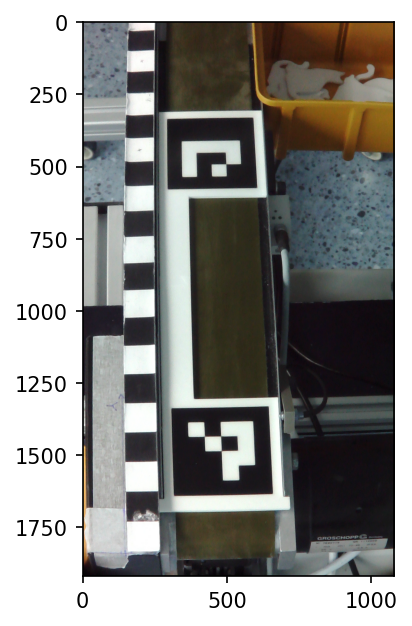

In [390]:
import cv2 as cv
from cv2 import aruco
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 150

aruco_dict = aruco.getPredefinedDictionary(aruco.DICT_4X4_100)
parameters = aruco.DetectorParameters()
detector = aruco.ArucoDetector(aruco_dict, parameters)

img_aruco = cv.imread('aruco_pic/aruco_0.png')
img_obj = cv.imread('obj/foto_10.png')

img_aruco_rotated = cv.rotate(img_aruco,2)
img_obj_rotated = cv.rotate(img_obj,2)


plt.imshow(img_aruco_rotated)

In [391]:
corners, ids, rejected = detector.detectMarkers(img_aruco_rotated)

(np.float64(-0.5), np.float64(1079.5), np.float64(1919.5), np.float64(-0.5))

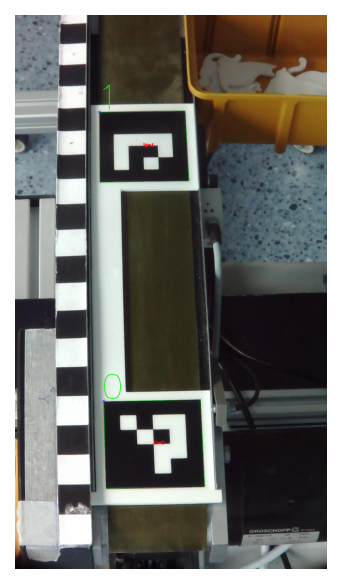

In [392]:
# Marker anzeichnen

if len(ids) > 0:
    img_markers = img_aruco_rotated.copy()
    aruco.drawDetectedMarkers(img_markers, corners, ids)
    
    for i, corner in enumerate(corners):
        top_left = corner[0][0]  # corner[marker][punkt][x/y]
        cv.putText(img_markers, str(ids[i][0]),
                   (int(top_left[0]) - 10, int(top_left[1]) - 10),
                   cv.FONT_HERSHEY_SIMPLEX, 4, (0, 255, 0), 2)
    
    #cv.imshow("Detected Markers", img_markers)
    #cv.waitKey(0)
    #cv.destroyAllWindows()
else:
    print("Keine Marker erkannt!")

fig = plt.imshow(img_markers, cmap = 'gray', vmin=0, vmax=255)
plt.axis('off')

In [393]:
SRC_COORDS = (np.array([[[ 0.,  0.],  [60., 0.],   [60., 60.],  [ 0.,60.], 
                                [ 0., 222.], [60., 222.], [60., 282.], [ 0., 282.]]], dtype= np.float32))
dstPoints = np.concatenate(corners, axis=1)
H, _ = cv.findHomography(srcPoints=SRC_COORDS, dstPoints=dstPoints, method=0)
H_inv = np.linalg.inv(H)

pts1 = np.float32([
    corners[1][0][0],  # oben-links
    corners[1][0][1],  # oben-rechts
    corners[0][0][3],  # unten-links
    corners[0][0][2],  # unten-rechts
])
pts2 = np.float32([
    [0,   0],
    [1080, 0],
    [0,   1920],
    [1080, 1920],
])
pts1_reshaped = pts1.astype(np.float32).reshape(-1, 1, 2)

# Pixel in Bild zu welt
world_frame = cv.perspectiveTransform(pts1_reshaped, H_inv)

# versatz - mit X und Y Offsets
offset_raw = np.array([
    [-6, +6],  # mm - X offset -6, Y offset -6
    [+6, +6],  # mm - X offset +6, Y offset -6
    [-6, -6],  # mm - X offset -6, Y offset +6
    [+6, -6]   # mm - X offset +6, Y offset +6
], dtype=np.float32)

offset = offset_raw.reshape(-1, 1, 2)
offset, offset_raw


(array([[[-6.,  6.]],
 
        [[ 6.,  6.]],
 
        [[-6., -6.]],
 
        [[ 6., -6.]]], dtype=float32),
 array([[-6.,  6.],
        [ 6.,  6.],
        [-6., -6.],
        [ 6., -6.]], dtype=float32))

In [394]:
pts1_2 = world_frame + offset



In [395]:
pts1_2_pixel = cv.perspectiveTransform(pts1_2, H)
pts1_2_pixel

array([[[ 260.13852,  317.8184 ]],

       [[ 619.44916,  312.81052]],

       [[ 278.4295 , 1669.7672 ]],

       [[ 691.6593 , 1660.7275 ]]], dtype=float32)

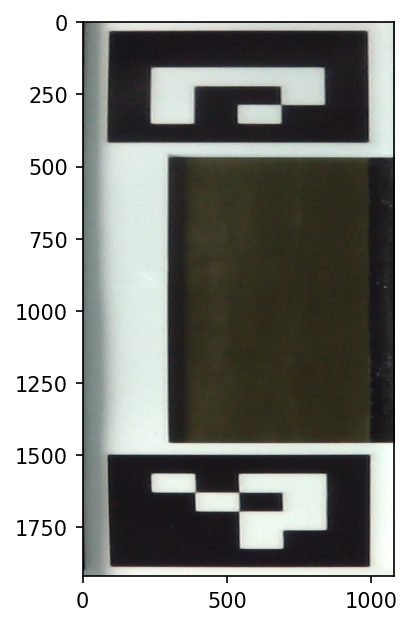

In [396]:
H_warp = cv.getPerspectiveTransform(pts1_2_pixel, pts2)
dst = cv.warpPerspective(img_aruco_rotated, H_warp, (1080, 1920))
plt.imshow(dst)

In [400]:
corners, ids, rejected = detector.detectMarkers(dst)
ids

array([[0],
       [1]], dtype=int32)

(np.float64(-0.5), np.float64(1079.5), np.float64(1919.5), np.float64(-0.5))

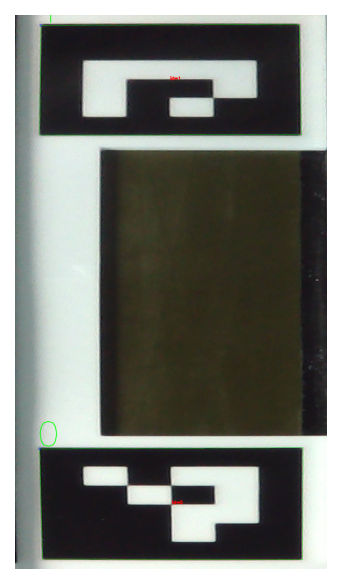

In [399]:
# Marker anzeichnen

if len(ids) > 0:
    img_markers = dst.copy()
    aruco.drawDetectedMarkers(img_markers, corners, ids)
    
    for i, corner in enumerate(corners):
        top_left = corner[0][0]  # corner[marker][punkt][x/y]
        cv.putText(img_markers, str(ids[i][0]),
                   (int(top_left[0]) - 10, int(top_left[1]) - 10),
                   cv.FONT_HERSHEY_SIMPLEX, 4, (0, 255, 0), 2)
    
    #cv.imshow("Detected Markers", img_markers)
    #cv.waitKey(0)
    #cv.destroyAllWindows()
else:
    print("Keine Marker erkannt!")

fig = plt.imshow(img_markers, cmap = 'gray', vmin=0, vmax=255)
plt.axis('off')